In [1]:
import time
%matplotlib widget

from scipy.constants import hbar, m_e, eV, physical_constants
## necessary modules
import numpy as np
from tqdm import tqdm
from matplotlib.patches import ConnectionPatch
import random
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy import integrate
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec
from pfapack.ctypes import pfaffian as cpf
from scipy import sparse
from scipy.linalg import ishermitian
from OneD_nanowire_utils import construct_Hamil, Diagonalize, Energy_spectrum, wavefunc, Energy_spectrum_phi, Energy_spectrum_v_VQD, pfaffian_calculation, Energy_tracker_phi, Energy_tracker_VQD, Topological_stability, Gen_disorder, Energy_GS_curvature_phi
from transport_quantities_1D_nanowire import capacitance, Capacitance_vs_phi, Capacitance_vs_VQD, inductance, inductance_vs_phi, inductance_vs_VQD
from config_1D_nanowire import ModelParams
import matplotlib.ticker as ticker
from joblib import Parallel, delayed
from copy import deepcopy

## define the pauli matrices
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
s0 = np.array([[1, 0], [0, 1]]) 

0.0


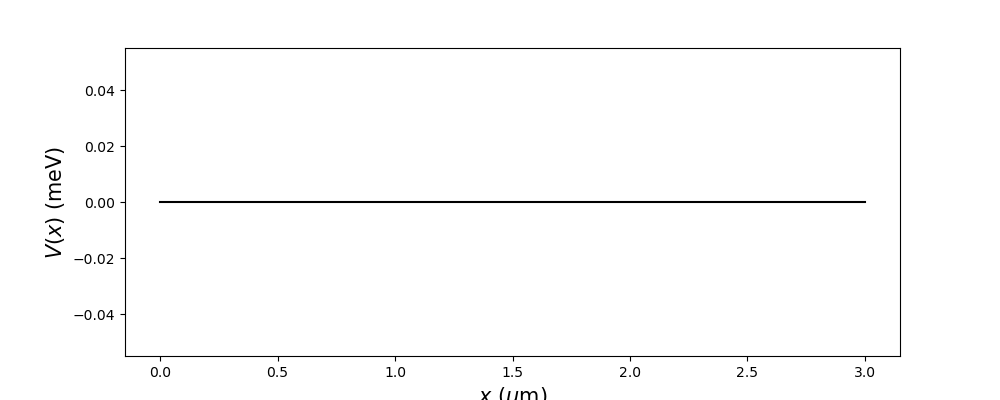

In [2]:
V0 = 0.0
N = 300
disorder_file = "Disorder_N_300_Broy.txt"
V_dis = V0*Gen_disorder(80,2.0,N)#np.array(np.loadtxt(open(disorder_file, "rb"), skiprows=0))
S = np.array([[0,0,1,0],[0,0,0,1],[1,0,0,0],[0,1,0,0]])
params = ModelParams(Disorder=V_dis[:N], chirality_op=S)
params.Length = N
print(np.sqrt(np.mean(V_dis**2.0)))
sigma = 50# was 70 previously
x0 = 0.0
x1 = params.Length
def Potential(x, V_0):
    return V_0*(
        np.exp(-((int(x/2) - x0) ** 2) / (2 * sigma**2))
        + np.exp(-((x1 - int(x/2)) ** 2) / (2 * sigma**2))
    )

x = np.linspace(0.0,3.0,params.Length)
pot_V = []
for i in range(0,2*params.Length,2):
    pot_V.append(Potential(i, V0))
pot_V = np.array(pot_V)
#V_dis = pot_V
params = ModelParams(Disorder=V_dis[:N])
params.Length = N
fig, ax_v = plt.subplots(figsize=(10, 4))
ax_v.plot(x, params.Disorder, label=r"$V(x)$", color="black")
ax_v.set_xlabel(r"$x$ ($\mu$m)", fontsize=15)
ax_v.set_ylabel(r"$V(x)$ (meV)", fontsize=15)
plt.show()

In [3]:
##Local Parameters##
mu_loc = 0.5
Ez_loc = 0.65
V_QD_low_loc = mu_loc - 0.1
V_QD_high_loc = mu_loc + 0.2
V_QD_points_loc = 400
phi_low_loc = 0.0
phi_high_loc = 2.0*np.pi
phi_points_loc = 400
gam_low_loc = 0.25
gam_high_loc = 1.25
gam_points_loc = 400
w_left_loc = 0.025
w_right_loc = 0.025
V_QD_loc = mu_loc + 0.045
No_QD_loc = False
params = ModelParams(
    mu=mu_loc, 
    Ez=Ez_loc, 
    w_left=w_left_loc, 
    w_right=w_right_loc, 
    V_QD_low=V_QD_low_loc, 
    V_QD_high=V_QD_high_loc, 
    V_QD_points=V_QD_points_loc, 
    Ez_low=gam_low_loc, 
    Ez_high=gam_high_loc, 
    Ez_points=gam_points_loc,
    phi_low=phi_low_loc,
    phi_high=phi_high_loc,
    phi_points=phi_points_loc, 
    V_QD=V_QD_loc,
    Disorder=V_dis[:N], 
    chirality_op=S,
    alpha=0.0,
    smsc_coupling=0.0,
    Delta0=0.0,
                     )
params.Length = N
gam_range_loc = np.linspace(gam_low_loc, gam_high_loc, gam_points_loc)
vqd_range_loc = np.linspace(V_QD_low_loc, V_QD_high_loc, V_QD_points_loc)
phi_range_loc = np.linspace(phi_low_loc, phi_high_loc, phi_points_loc)

In [4]:
# Majorana/BdG parameters
params.alpha = 1.4
params.smsc_coupling = 0.2
params.Delta0 = 0.3

params.mu = mu_loc = 0.5
params.Ez = Ez_loc = 0.65
params.w_left = params.w_right = 0.025
params.Disorder = np.zeros(params.Length)

# Common window broad enough to contain both normal- and Majorana-model features
params.V_QD_low = 0.58
params.V_QD_high = 0.79
params.V_QD_points = 41       # preliminary map; increase later
params.phi_low = 0.0
params.phi_high = 2.0*np.pi
params.phi_points = 101

V_QD_BdG = np.linspace(
    params.V_QD_low,
    params.V_QD_high,
    params.V_QD_points
)

phi_BdG = np.linspace(
    params.phi_low,
    params.phi_high,
    params.phi_points
)

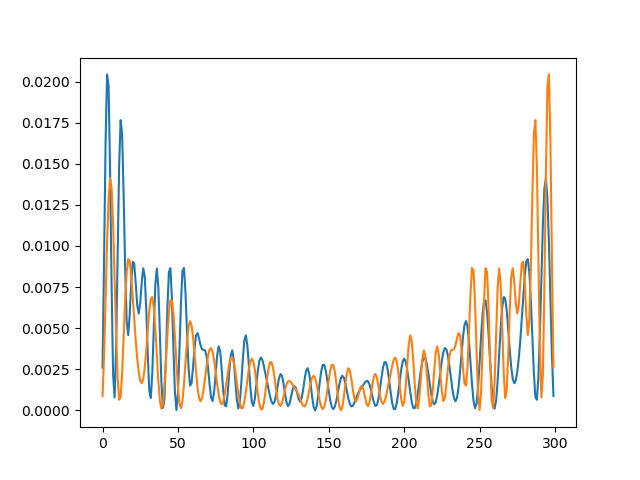

In [6]:
wf1, wf2, _, _, _ = wavefunc(1.58, 0.6, phi0=0.0, No_QD=True, params=params)
fig, ax = plt.subplots()
ax.plot(wf1)
ax.plot(wf2)
plt.show()

In [13]:
import numpy as np
from scipy.special import expit
from copy import deepcopy

from config_1D_nanowire import ModelParams
from transport_quantities_1D_nanowire import Capacitance_vs_phi


# Only needed by functions that use the Pfaffian representation
S = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0],
    [0, 1, 0, 0],
])


# Clean topological benchmark parameters
p = ModelParams(
    Length=300,
    t=16.56,
    alpha=1.4,
    mu=0.50,
    Delta0=0.30,
    Ez=0.65,
    smsc_coupling=0.20,
    w_left=0.015,
    w_right=0.015,
    V_QD=0.635,
    phi_low=0.0,
    phi_high=2.0 * np.pi,
    phi_points=101,
    w=0.0,
    eta=0.002,
    Disorder=np.zeros(300),
    chirality_op=S,
)


# Calculate capacitances and the energies of the same tracked parity states
C_even, C_odd, E_even, E_odd = Capacitance_vs_phi(
    mu=p.mu,
    Ez=p.Ez,
    params=p,
    consider_all_states=False,
    number_of_states=40,
    n_jobs=6,
    n_return=6,
    return_parity_energies=True,
)

phi = np.linspace(
    p.phi_low,
    p.phi_high,
    p.phi_points,
)


# Equilibrium Boltzmann probabilities
T = 0.050                     # kelvin
k_B = 8.617333262e-2          # meV/K
kBT = k_B * T

delta_E = 0.5*(E_odd - E_even)

p_even = expit(delta_E / kBT)
p_odd = expit(-delta_E / kBT)


# Phenomenological capacitance/readout width
sigma_C = 0.105               # fF


np.savez_compressed(
    "clean_BdG_boltzmann_Cphi.npz",
    phi=phi,
    C_even=C_even,
    C_odd=C_odd,
    E_even=E_even,
    E_odd=E_odd,
    delta_E=delta_E,
    p_even=p_even,
    p_odd=p_odd,
    T_K=T,
    kBT_meV=kBT,
    sigma_C_fF=sigma_C,
    mu_meV=p.mu,
    Ez_meV=p.Ez,
    V_QD_meV=p.V_QD,
    alpha_meV=p.alpha,
    Delta0_meV=p.Delta0,
    smsc_coupling_meV=p.smsc_coupling,
    eta_meV=p.eta,
)

print("Saved clean_BdG_boltzmann_Cphi.npz")
print("Probability check:", np.max(np.abs(p_even + p_odd - 1.0)))
print(
    "Delta E range:",
    1e3 * np.min(delta_E),
    "to",
    1e3 * np.max(delta_E),
    "micro-eV",
)

capacitance phi sweep: 100%|██████████| 101/101 [00:00<00:00, 102.26it/s]


Saved clean_BdG_boltzmann_Cphi.npz
Probability check: 1.1102230246251565e-16
Delta E range: -4.691252223952 to 6.62203347301086 micro-eV


In [13]:
import numpy as np
import random
from copy import deepcopy

Length_common = 300
t_common = 16.56
alpha_common = 1.4
Ez_common = 0.65

w_left_common = 0.025
w_right_common = 0.025

# Start with moderate disorder
W0 = 1.2  # meV RMS disorder strength

disorder_file = "Disorder_N_300_Broy.txt"
V_dis = W0*np.array(np.loadtxt(open(disorder_file, "rb"), skiprows=0))

# ============================================================
# Topological BdG parameters
# ============================================================

params_BdG = deepcopy(params)

params_BdG.Length = Length_common
params_BdG.t = t_common
params_BdG.alpha = alpha_common

params_BdG.smsc_coupling = 0.2
params_BdG.Delta0 = 0.3

params_BdG.mu = mu_BdG = 0.50
params_BdG.Ez = Ez_BdG = Ez_common

params_BdG.w_left = w_left_common
params_BdG.w_right = w_right_common

params_BdG.Disorder = V_dis

# QD window used for the topological response calculation
V_ref_BdG = 0.686

params_BdG.V_QD_low = V_ref_BdG - 0.100
params_BdG.V_QD_high = V_ref_BdG + 0.100
params_BdG.V_QD_points = 81

params_BdG.phi_low = 0.0
params_BdG.phi_high = 2.0 * np.pi
params_BdG.phi_points = 101

V_QD_BdG = np.linspace(
    params_BdG.V_QD_low,
    params_BdG.V_QD_high,
    params_BdG.V_QD_points
)

phi_BdG = np.linspace(
    params_BdG.phi_low,
    params_BdG.phi_high,
    params_BdG.phi_points
)

In [29]:
import numpy as np

from copy import deepcopy
from tqdm import tqdm
from joblib import Parallel, delayed

mu_values = np.linspace(
    -0.50,
     3.50,
    200
)

Ez_values = np.linspace(
    0.25,
    1.2,
    100
)

def calculate_Ts_row(
    mu0,
    Ez_values,
    params
):
    Ts_row = []

    for Ez0 in Ez_values:
        p = deepcopy(params)

        # Maintain V_QD - E_z = 0.036 meV
        p.V_QD = Ez0 + 0.036

        Ts_row.append(
            Topological_stability(
                mu=mu0,
                Ez=Ez0,
                No_QD=False,
                params=p
            )
        )

    return np.asarray(Ts_row)

rows = Parallel(
    n_jobs=6,
    backend="loky"
)(
    delayed(calculate_Ts_row)(
        mu0,
        Ez_values,
        params_BdG
    )
    for mu0 in tqdm(
        mu_values,
        desc="Calculating T_s"
    )
)

Ts_map = np.asarray(rows)

Calculating T_s: 100%|██████████| 200/200 [49:16<00:00, 14.78s/it]


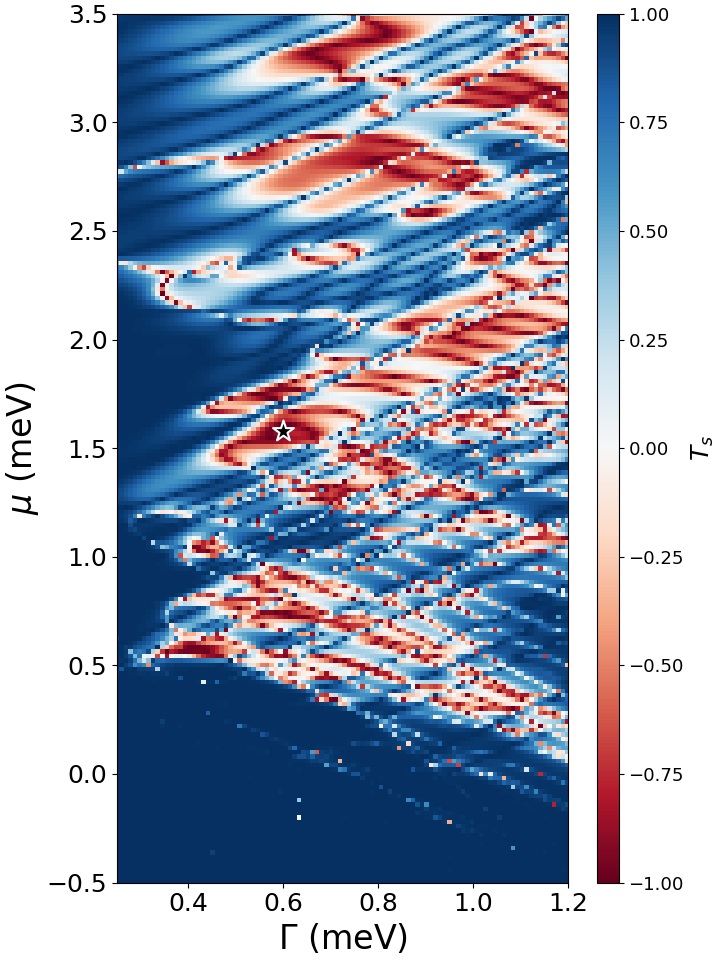

In [ ]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(7.2, 9.6),
    constrained_layout=True
)

im = ax.pcolor(
    Ez_values,
    mu_values,
    Ts_map,
    shading="auto",
    cmap="RdBu",
    vmin=-1.0,
    vmax=1.0,
    rasterized=False
)

ax.set_xlabel(
    r"$\Gamma$ (meV)",
    fontsize=24
)

ax.set_ylabel(
    r"$\mu$ (meV)",
    fontsize=24
)

ax.set_xlim(0.25, 1.2)
ax.set_ylim(-0.5, 3.5)

ax.tick_params(
    axis="both",
    labelsize=18
)

Gamma_star = 0.6
mu_star = 1.58

ax.scatter(
    Gamma_star,
    mu_star,
    marker="*",
    s=250,
    facecolor="black",
    edgecolor="white",
    linewidth=1.5,
    zorder=10
)

cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.02,
    aspect=40
)

cbar.set_label(
    r"$T_s$",
    fontsize=18
)

cbar.ax.tick_params(
    labelsize=13
)
#plt.savefig("/Users/binayyakroy/Normal_wire_sim/Loss_paper_comp_figs/Invariant_map.png", dpi=300)
plt.show()

In [22]:
import numpy as np
from copy import deepcopy
from tqdm import tqdm

# ============================================================
# Topological BdG (mu, V_QD, phi) capacitance data
# ============================================================

mu_ref_BdG = 0.50
Ez_BdG = 0.65

V_ref_BdG = 0.686

print(
    "Initial BdG V_QD reference:",
    V_ref_BdG,
    "meV",
)

mu_offsets = np.array([
    -0.050,
    -0.030,
    -0.015,
     0.000,
     0.015,
     0.030,
     0.050,
])

mu_values_BdG = mu_ref_BdG + mu_offsets

# Identical detuning interval to the normal calculation
delta_V_QD = np.linspace(-0.1, 0.1, 41)
V_QD_values_BdG = V_ref_BdG + delta_V_QD

params_scan = deepcopy(params)
params_scan.phi_low = 0.0
params_scan.phi_high = 2.0 * np.pi
params_scan.phi_points = 101

phi_values = np.linspace(
    params_scan.phi_low,
    params_scan.phi_high,
    params_scan.phi_points,
)

shape = (
    len(mu_values_BdG),
    len(V_QD_values_BdG),
    len(phi_values),
)

C_even_BdG = np.full(shape, np.nan)
C_odd_BdG = np.full(shape, np.nan)

for i_mu, mu0 in enumerate(
    tqdm(mu_values_BdG, desc="BdG: mu sweep")
):
    for i_vqd, V_QD0 in enumerate(V_QD_values_BdG):

        p = deepcopy(params_scan)
        p.V_QD = V_QD0

        C_even, C_odd = Capacitance_vs_phi(
            mu=mu0,
            Ez=Ez_BdG,
            params=p,
            consider_all_states=False,
            number_of_states=60,
            n_jobs=6,
            n_return=6,
        )

        C_even_BdG[i_mu, i_vqd, :] = C_even
        C_odd_BdG[i_mu, i_vqd, :] = C_odd

    # Checkpoint after every completed mu slice
    np.savez_compressed(
        "BdG_mu_VQD_phi_capacitance.npz",
        mu=mu_values_BdG,
        mu_offset=mu_offsets,
        V_QD=V_QD_values_BdG,
        delta_V_QD=delta_V_QD,
        phi=phi_values,
        C_even=C_even_BdG,
        C_odd=C_odd_BdG,
        mu_ref=mu_ref_BdG,
        V_QD_ref=V_ref_BdG,
        Ez=Ez_BdG,
        completed_mu_slices=i_mu + 1,
    )

print("Saved BdG_mu_VQD_phi_capacitance.npz")
print("Array shape:", C_even_BdG.shape)

Initial BdG V_QD reference: 0.686 meV


BdG: mu sweep: 100%|██████████| 7/7 [09:09<00:00, 78.43s/it]

Saved BdG_mu_VQD_phi_capacitance.npz
Array shape: (7, 41, 101)


In [8]:
C_even_BdG = np.zeros((len(V_QD_BdG), len(phi_BdG)))
C_odd_BdG = np.zeros_like(C_even_BdG)

start = time.time()

for i, V_QD0 in enumerate(tqdm(V_QD_BdG, desc="BdG V_QD sweep")):

    p = deepcopy(params)
    p.V_QD = V_QD0

    C_even_BdG[i], C_odd_BdG[i] = Capacitance_vs_phi(
        mu_loc,
        Ez_loc,
        params=p,
        consider_all_states=False,  # False means sparse/truncated here
        number_of_states=60,
        n_jobs=6
    )

print(f"Elapsed time: {(time.time() - start)/60:.2f} min")
print(C_even_BdG.shape, C_odd_BdG.shape)

BdG V_QD sweep: 100%|██████████| 41/41 [01:23<00:00,  2.04s/it]

Elapsed time: 1.39 min
(41, 101) (41, 101)


In [9]:
np.savez_compressed(
    "BdG_Majorana_capacitance_map.npz",
    V_QD=V_QD_BdG,
    phi=phi_BdG,
    C_even=C_even_BdG,
    C_odd=C_odd_BdG,
    mu=mu_loc,
    Ez=Ez_loc,
    alpha=params.alpha,
    Delta0=params.Delta0,
    smsc_coupling=params.smsc_coupling,
    w_left=params.w_left,
    w_right=params.w_right,
    eta=params.eta,
    Length=params.Length,
    number_of_states=60
)

In [ ]:
import numpy as np
from copy import deepcopy
from tqdm import tqdm

# ============================================================
# Topological BdG (mu, V_QD, phi) capacitance data
# ============================================================

mu_ref_BdG = 0.50
Ez_BdG = 0.65

# Previous convention: E_D = V_QD - mu, without QD Zeeman
V_ref_BdG_old = 0.545

# New convention: lower QD branch E_D = V_QD - Ez
V_ref_BdG = (
    V_ref_BdG_old
    - mu_ref_BdG
    + Ez_BdG
)

print(
    "Initial BdG V_QD reference:",
    V_ref_BdG,
    "meV",
)

mu_offsets = np.array([
    -0.050,
    -0.030,
    -0.015,
     0.000,
     0.015,
     0.030,
     0.050,
])

mu_values_BdG = mu_ref_BdG + mu_offsets

# Identical detuning interval to the normal calculation
delta_V_QD = np.linspace(-0.075, 0.075, 61)
V_QD_values_BdG = V_ref_BdG + delta_V_QD

params_scan = deepcopy(params)
params_scan.phi_low = 0.0
params_scan.phi_high = 2.0 * np.pi
params_scan.phi_points = 61

phi_values = np.linspace(
    params_scan.phi_low,
    params_scan.phi_high,
    params_scan.phi_points,
)

shape = (
    len(mu_values_BdG),
    len(V_QD_values_BdG),
    len(phi_values),
)

C_even_BdG = np.full(shape, np.nan)
C_odd_BdG = np.full(shape, np.nan)

for i_mu, mu0 in enumerate(
    tqdm(mu_values_BdG, desc="BdG: mu sweep")
):
    for i_vqd, V_QD0 in enumerate(V_QD_values_BdG):

        p = deepcopy(params_scan)
        p.V_QD = V_QD0

        C_even, C_odd = Capacitance_vs_phi(
            mu=mu0,
            Ez=Ez_BdG,
            params=p,
            consider_all_states=False,
            number_of_states=60,
            n_jobs=6,
            n_return=6,
        )

        C_even_BdG[i_mu, i_vqd, :] = C_even
        C_odd_BdG[i_mu, i_vqd, :] = C_odd

    # Checkpoint after every completed mu slice
    np.savez_compressed(
        "BdG_mu_VQD_phi_capacitance.npz",
        mu=mu_values_BdG,
        mu_offset=mu_offsets,
        V_QD=V_QD_values_BdG,
        delta_V_QD=delta_V_QD,
        phi=phi_values,
        C_even=C_even_BdG,
        C_odd=C_odd_BdG,
        mu_ref=mu_ref_BdG,
        V_QD_ref=V_ref_BdG,
        Ez=Ez_BdG,
        completed_mu_slices=i_mu + 1,
    )

print("Saved BdG_mu_VQD_phi_capacitance.npz")
print("Array shape:", C_even_BdG.shape)

BdG V_QD spectrum: 100%|██████████| 101/101 [00:01<00:00, 96.34it/s]


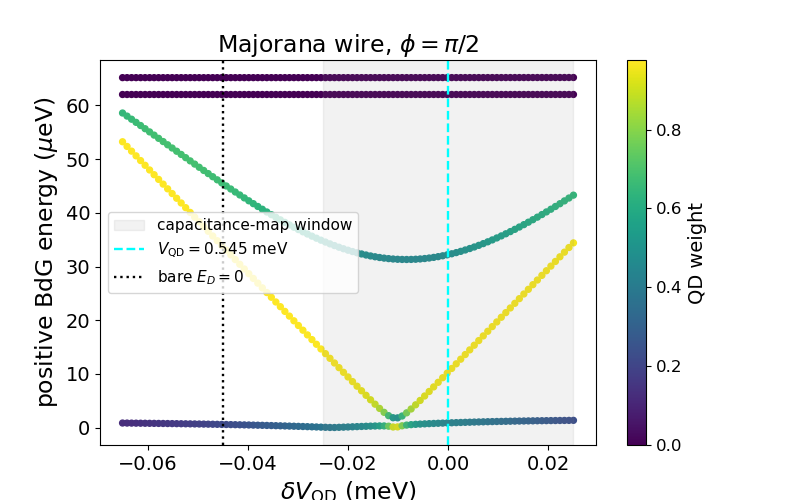

In [8]:
# Majorana low-energy spectrum needed for corrected diagram

V_ref_BdG = 0.545
V_sweep = np.linspace(0.480, 0.570, 101)
phi_level = np.pi / 2
num_levels = 5

def _spectrum_worker(V_QD):
    p = deepcopy(params)
    p.V_QD = V_QD

    H = construct_Hamil(
        mu_loc, Ez_loc, phi_level,
        params=p, No_QD=False
    )

    energies, states = Diagonalize(
        H, extract_exact=False, num_eigvals=14
    )

    positive = np.where(energies > 0)[0]
    positive = positive[np.argsort(energies[positive])[:num_levels]]

    # Total particle-plus-hole weight on the QD
    qd = slice(4 * p.Length, 4 * p.Length + 4)
    qd_weight = np.sum(np.abs(states[qd, positive])**2, axis=0)

    return energies[positive], qd_weight


results = Parallel(n_jobs=6, backend="loky")(
    delayed(_spectrum_worker)(V_QD)
    for V_QD in tqdm(V_sweep, desc="BdG V_QD spectrum")
)

E_positive = np.array([r[0] for r in results])
QD_weight = np.array([r[1] for r in results])
dV_BdG = V_sweep - V_ref_BdG

np.savez(
    "BdG_Majorana_energy_levels.npz",
    V_QD=V_sweep,
    dV=dV_BdG,
    E_positive=E_positive,
    QD_weight=QD_weight,
    phi=phi_level,
    V_ref=V_ref_BdG
)

fig, ax = plt.subplots(figsize=(8, 5))

for n in range(num_levels):
    sc = ax.scatter(
        dV_BdG,
        1e3 * E_positive[:, n],
        c=QD_weight[:, n],
        cmap="viridis",
        vmin=0,
        vmax=np.max(QD_weight),
        s=18
    )

# Range covered by the existing capacitance heatmap
ax.axvspan(-0.025, 0.025, color="gray", alpha=0.10,
           label="capacitance-map window")

# Previous optimized working point
ax.axvline(0, color="cyan", ls="--", lw=1.7,
           label=r"$V_{\rm QD}=0.545$ meV")

# Bare dot zero: V_QD = mu
ax.axvline(
    mu_loc - V_ref_BdG,
    color="black", ls=":", lw=1.7,
    label=r"bare $E_D=0$"
)

ax.set_xlabel(r"$\delta V_{\rm QD}$ (meV)", fontsize=17)
ax.set_ylabel(r"positive BdG energy ($\mu$eV)", fontsize=17)
ax.set_title(r"Majorana wire, $\phi=\pi/2$", fontsize=17)
ax.tick_params(labelsize=14)
ax.legend(fontsize=11)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("QD weight", fontsize=14)
cbar.ax.tick_params(labelsize=12)
"""
plt.savefig(
    "BdG_Majorana_energy_levels.png",
    dpi=400, bbox_inches="tight"
)
"""
plt.show()

100%|██████████| 101/101 [00:00<00:00, 105.22it/s]


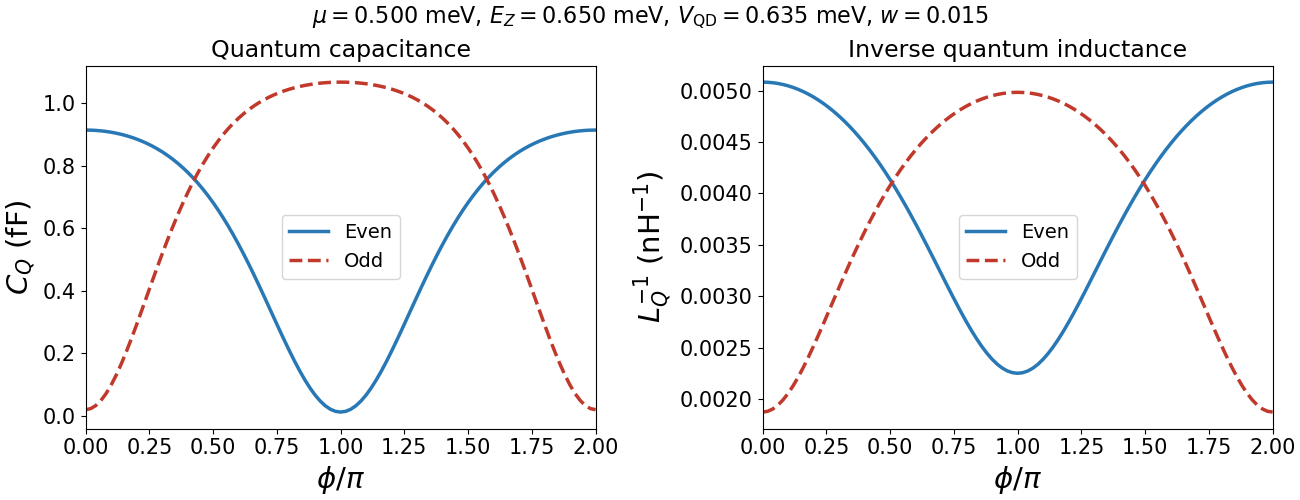

In [12]:
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parameters to choose
# ============================================================

mu0 = 0.5          # wire chemical potential, meV
Ez0 = 0.65          # Zeeman energy, meV
V_QD0 = 0.635       # dot potential, meV
w_QD = 0.015        # dot-wire coupling at both ends

phi_points = 101
n_jobs = 6

# Preserve all other settings: disorder, alpha, Delta, Length, etc.
p = deepcopy(params)

p.mu = mu0
p.Ez = Ez0
p.V_QD = V_QD0
p.w_left = w_QD
p.w_right = w_QD

p.phi_low = 0.0
p.phi_high = 2.0 * np.pi
p.phi_points = phi_points

phi = np.linspace(p.phi_low, p.phi_high, p.phi_points)

# ============================================================
# Calculate capacitance
# ============================================================

C_even, C_odd = Capacitance_vs_phi(
    mu0,
    Ez0,
    params=p,
    consider_all_states=False,
    number_of_states=40,
    n_jobs=n_jobs
)

# ============================================================
# Calculate inverse quantum inductance
# ============================================================

Le_P, Le_D, Lo_P, Lo_D = inductance_vs_phi(
    mu0,
    Ez0,
    params=p,
    include_diamagnetic_term=True,
    consider_all_states=False,
    number_of_states=40,
    n_jobs=n_jobs
)

# Total = paramagnetic + diamagnetic contributions
Linv_even = Le_P + Le_D
Linv_odd = Lo_P + Lo_D

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    constrained_layout=True
)

# Capacitance
axes[0].plot(
    phi / np.pi,
    C_even,
    color="#2878B5",
    lw=2.5,
    label="Even"
)
axes[0].plot(
    phi / np.pi,
    C_odd,
    color="#C0392B",
    lw=2.5,
    ls="--",
    label="Odd"
)
axes[0].set_ylabel(r"$C_Q$ (fF)", fontsize=21)
axes[0].set_title("Quantum capacitance", fontsize=17)
axes[0].legend(fontsize=14)

# Inverse inductance
axes[1].plot(
    phi / np.pi,
    Linv_even,
    color="#2878B5",
    lw=2.5,
    label="Even"
)
axes[1].plot(
    phi / np.pi,
    Linv_odd,
    color="#C0392B",
    lw=2.5,
    ls="--",
    label="Odd"
)
axes[1].set_ylabel(
    r"$L_Q^{-1}$ (nH$^{-1}$)",
    fontsize=21
)
axes[1].set_title("Inverse quantum inductance", fontsize=17)
axes[1].legend(fontsize=14)

for ax in axes:
    ax.set_xlabel(r"$\phi/\pi$", fontsize=21)
    ax.set_xlim(0, 2)
    ax.tick_params(labelsize=15)

fig.suptitle(
    rf"$\mu={mu0:.3f}$ meV, "
    rf"$E_Z={Ez0:.3f}$ meV, "
    rf"$V_{{\rm QD}}={V_QD0:.3f}$ meV, "
    rf"$w={w_QD:.3f}$",
    fontsize=16
)

plt.show()

100%|██████████| 200/200 [00:08<00:00, 24.91it/s]


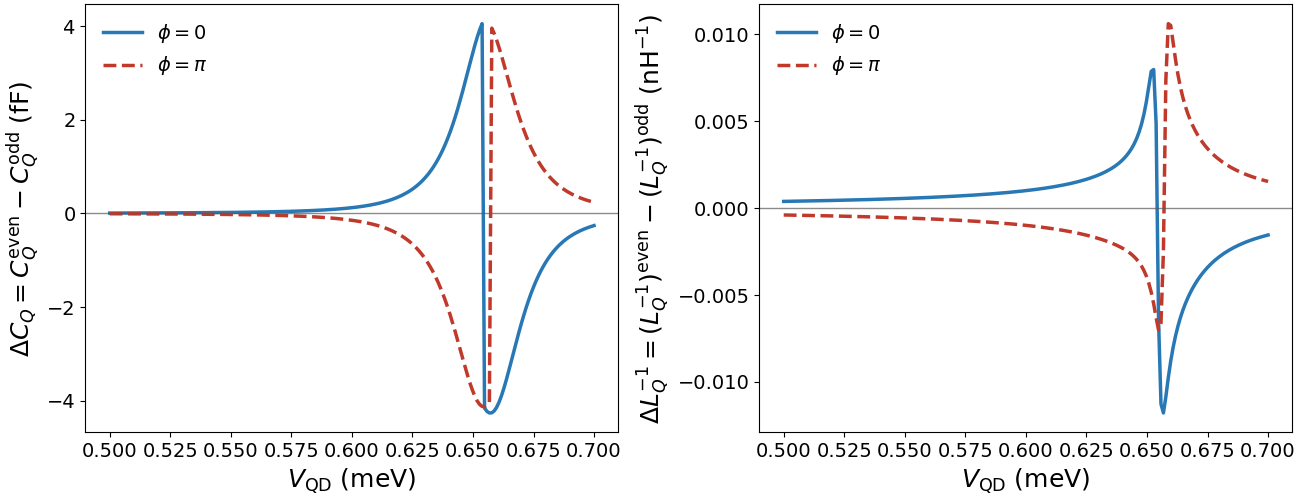

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

# ============================================================
# Parameters to choose
# ============================================================

mu0 = 0.5
Ez0 = 0.65
w_QD = 0.01

V_QD_low = 0.5
V_QD_high = 0.7
V_QD_points = 200

n_jobs = 6

p = deepcopy(params)
p.mu = mu0
p.Ez = Ez0
p.w_left = w_QD
p.w_right = w_QD
p.V_QD_low = V_QD_low
p.V_QD_high = V_QD_high
p.V_QD_points = V_QD_points

V_QD = np.linspace(V_QD_low, V_QD_high, V_QD_points)

# ============================================================
# Data generation
# ============================================================

# Returns ΔC_Q = C_Q^even - C_Q^odd at phi = 0 and pi
dC_0, dC_pi = Capacitance_vs_VQD(
    mu0, Ez0,
    params=p,
    consider_all_states=False,
    number_of_states=60,
    n_jobs=n_jobs
)

# Returns paramagnetic and diamagnetic contributions separately
dLP_0, dLD_0, dLP_pi, dLD_pi = inductance_vs_VQD(
    mu0, Ez0,
    params=p,
    include_diamagnetic_term=True,
    consider_all_states=False,
    number_of_states=60,
    n_jobs=n_jobs
)

# Total inverse-inductance contrast
dLinv_0 = dLP_0 + dLD_0
dLinv_pi = dLP_pi + dLD_pi

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    constrained_layout=True
)

axes[0].plot(
    V_QD, dC_0,
    color="#2878B5", lw=2.5,
    label=r"$\phi=0$"
)
axes[0].plot(
    V_QD, dC_pi,
    color="#C0392B", lw=2.5, ls="--",
    label=r"$\phi=\pi$"
)
axes[0].set_ylabel(
    r"$\Delta C_Q=C_Q^{\rm even}-C_Q^{\rm odd}$ (fF)",
    fontsize=18
)

axes[1].plot(
    V_QD, dLinv_0,
    color="#2878B5", lw=2.5,
    label=r"$\phi=0$"
)
axes[1].plot(
    V_QD, dLinv_pi,
    color="#C0392B", lw=2.5, ls="--",
    label=r"$\phi=\pi$"
)
axes[1].set_ylabel(
    r"$\Delta L_Q^{-1}=(L_Q^{-1})^{\rm even}"
    r"-(L_Q^{-1})^{\rm odd}$ (nH$^{-1}$)",
    fontsize=18
)

for ax in axes:
    ax.set_xlabel(r"$V_{\rm QD}$ (meV)", fontsize=18)
    ax.tick_params(labelsize=14)
    ax.axhline(0, color="0.35", lw=1, alpha=0.7)
    ax.legend(frameon=False, fontsize=14)

plt.show()

In [39]:
import numpy as np
from copy import deepcopy

# ============================================================
# Common parameters for the final comparison
# ============================================================

Length_common = 300
t_common = 16.56
alpha_common = 1.4

mu_common = 1.58
Ez_common = 0.60

w_left_common = 0.025
w_right_common = 0.025

W0 = 1.2  # meV RMS disorder strength

disorder_file = "Disorder_N_300_Broy.txt"

# Assumes the saved profile has zero mean and unit RMS
V_dis = W0 * np.loadtxt(disorder_file)

# Common detuning axis used around each model's own resonance
delta_V_QD = np.linspace(-0.100, 0.100, 41)

# ============================================================
# Topological BdG parameters
# ============================================================

params_BdG = deepcopy(params)

params_BdG.Length = Length_common
params_BdG.t = t_common
params_BdG.alpha = alpha_common

params_BdG.smsc_coupling = 0.2
params_BdG.Delta0 = 0.3

params_BdG.mu = mu_BdG = mu_common
params_BdG.Ez = Ez_BdG = Ez_common

params_BdG.w_left = w_left_common
params_BdG.w_right = w_right_common

params_BdG.Disorder = V_dis

# Resonance tracks the Zeeman-split QD level:
# V_QD^res = Ez + 0.036 meV
V_ref_BdG = Ez_BdG + 0.036   # 0.636 meV

params_BdG.V_QD_low = V_ref_BdG - 0.100
params_BdG.V_QD_high = V_ref_BdG + 0.100
params_BdG.V_QD_points = 41

params_BdG.phi_low = 0.0
params_BdG.phi_high = 2.0 * np.pi
params_BdG.phi_points = 101

V_QD_BdG = V_ref_BdG + delta_V_QD

phi_BdG = np.linspace(
    params_BdG.phi_low,
    params_BdG.phi_high,
    params_BdG.phi_points
)

C_even_BdG = np.zeros(
    (len(V_QD_BdG), len(phi_BdG))
)

C_odd_BdG = np.zeros_like(C_even_BdG)

for i_vqd, V_QD0 in enumerate(V_QD_BdG):
    p = deepcopy(params_BdG)
    p.V_QD = V_QD0

    C_even, C_odd = Capacitance_vs_phi(
        mu=mu_BdG,
        Ez=Ez_BdG,
        params=p,
        consider_all_states=False,
        number_of_states=60,
        n_jobs=6,
        n_return=6,
    )

    C_even_BdG[i_vqd] = C_even
    C_odd_BdG[i_vqd] = C_odd

np.savez_compressed(
    "BdG_RSOC_disorder_capacitance_map.npz",
    mu=mu_BdG,
    Ez=Ez_BdG,
    W0=W0,
    V_QD_ref=V_ref_BdG,
    V_QD=V_QD_BdG,
    delta_V_QD=delta_V_QD,
    phi=phi_BdG,
    C_even=C_even_BdG,
    C_odd=C_odd_BdG,
)

  0%|          | 0/101 [00:00<?, ?it/s]

100%|██████████| 101/101 [00:01<00:00, 56.63it/s]
